In [282]:
import numpy as np
import pickle
from stat_utils import grenander_pdf, GeneralParams
import jax.random as jrand
from abm_event import conditional_sample
from abm_ll import city_ll
import math


#def metropolis_o(current, current_likelihood, c_params, c_events, params, jrand.PRNGKey(i), num_samples=int(1e5)):

    # propose a new state
    # compute likelihood of new state

    # proposed = conditional_sample(c_params, params, jrand.PRNGKey(i), num_samples=int(1e5))
    # city_distr = grenander_pdf(proposed+1)
    # proposed_ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)

    # ratio = current_likelihood / proposed_ll
    # p = np.random.uniform(0,1)
    # if ratio > p:
    #     return proposed, proposed_ll

    # return current, current_likelihood


def mcmc_metropolis_o(iter=10000):

    with open('data/county_data.pkl', 'rb') as f:
        city_data = pickle.load(f)

    def hasna(p):
        return any(np.isnan(x) for x in p)

    city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}
    city_data_f = [c for c in city_data.values() if c['events']]
    city_data_base = [c for c in city_data.values() if not c['events']]
    city_base_ind = np.arange(len(city_data_base))

    np.random.seed(1)
    np.random.shuffle(city_base_ind)
    subsampled_city_data_base = np.array(city_data_base)[city_base_ind[:400]]
    subsampled_city_data = np.concatenate([city_data_f, subsampled_city_data_base])

    c = subsampled_city_data[10]
    params = GeneralParams(propensity=1e-8, walk_radius=40, arm_bias=1.0, arm_weight=1.0, atrisk_gathering_rate=1e-8)
    c_params = c['params']
    c_events = c['events']

    curr = conditional_sample(c_params, params, jrand.PRNGKey(i), num_samples=int(1e5))
    city_distr = grenander_pdf(curr+1)
    curr_ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)

    samples = np.array([])

    # loop
    for i in range(iter):
        curr, curr_ll = metropolis(curr, curr_ll, c_params, c_events, params, jrand.PRNGKey(i), num_samples=int(1e5))
        samples.append(curr)

    return samples

In [283]:
def metropolis(curr, current_likelihood, params, rng, proposal_pdf, proposal_func, prior_pdf, likelihood_func):
    # perturb existing parameters and propose a new state
    params, proposed = proposal_func(params, rng)
    # compute likelihood of new state
    proposed_ll = likelihood_func(proposed)

    proposed_posterior = prior_pdf(proposed) * proposed_ll
    current_posterior = prior_pdf(curr) * current_likelihood
    acceptance_probability = min(1,  proposed_posterior * proposal_pdf(proposed) / current_posterior * proposal_pdf(curr))

    p = np.random.uniform(0,1)
    if p < acceptance_probability:
        return proposed, proposed_ll, params
    return curr, current_likelihood, params


def mcmc_metropolis(likelihood_func, params, rng, proposal_pdf, proposal_func, prior_pdf, iter=10000):
    samples = np.array([])
    states = np.array([])
    ps = np.array([])

    # propose initial state
    params, curr = proposal_func(params, rng)
    # calculate likelihood of initial state
    curr_ll = likelihood_func(curr)

    samples = np.append(samples, curr_ll)
    ps = np.append(ps, params)
    states = np.append(states, curr)

    # update sampler
    for i in range(iter):
        curr, curr_ll, params = metropolis(curr, curr_ll, params, rng, proposal_pdf, proposal_func, prior_pdf, likelihood_func)
        samples = np.append(samples, curr_ll)
        ps = np.append(ps, params)
        states = np.append(states, curr)

    return samples, ps, states

In [284]:
import scipy.stats

def prior_pdf(x, mu=1, sigma=1):
    return scipy.stats.norm(mu, sigma).pdf(x)

def proposal_func(mu, rng):
    x = np.random.uniform(low=mu-1, high=mu+1, size=1)
    return x, x

def proposal_pdf(mu):
    return 1/2

def likelihood_func(x, mu=1, sigma=1):
    return scipy.stats.norm(mu, sigma).pdf(x)


In [285]:
it = 500
s, p, st = mcmc_metropolis(likelihood_func, 1, np.random.default_rng(), proposal_pdf, proposal_func, prior_pdf, iter=10000)

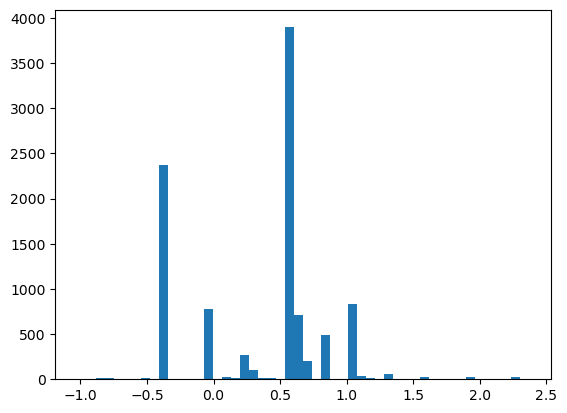

In [286]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(st, bins=50)
plt.show()

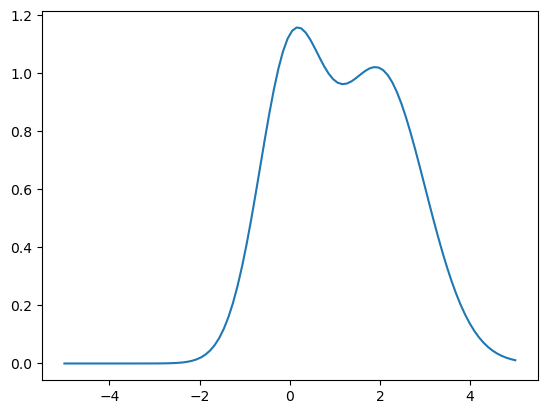

In [390]:
# ok i'm goign to go insane

# mcmc with a known posterior

# reference: https://github.com/abdulfatir/sampling-methods-numpy/blob/master/Metropolis-Hastings.ipynb

# target distribution / posterior: = P(x)
def posterior_pdf(x):
    return np.exp(-x**2)

# proposal function: =Q(x|xt), xt=prev value
def proposal_pdf(x, xt):
    return scipy.stats.norm(loc=xt, scale=1).pdf(x) # normal with scale=1, mean=mu, mu=xt (prev value), x=x

def proposal_func(x):
    return np.random.normal(x, 1) # normal with scale=1, mean=x

P = lambda x: np.exp(-x**2) + np.exp(-(x-2)**2 * 1/2)
Q = lambda x, xt: scipy.stats.norm(loc=xt, scale=1).pdf(x)

xs = np.linspace(-5, 5, 100)

plt.figure()
plt.plot(xs, P(xs))
plt.show()


In [391]:
x0 = 0
xt = proposal_func(x0) # xt = proposal/ candidate

samples = []
for i in range(10000):
    proposed = proposal_func(xt)
    acceptance_ratio = P(proposed) * Q(xt, proposed) / P(xt) * Q(proposed, xt)
    p = np.random.uniform(0,1)
    if p < acceptance_ratio:
        xt = proposed
    samples.append(xt)

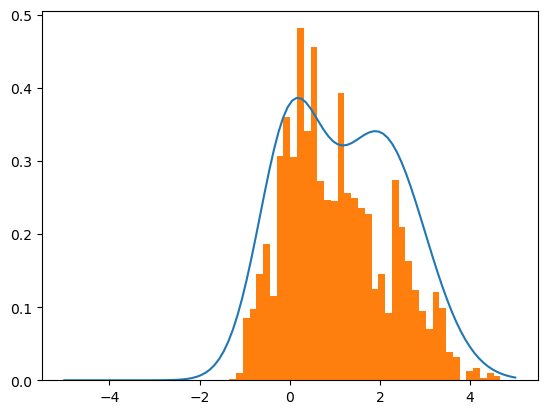

In [396]:
plt.figure()
plt.plot(xs, P(xs)/3)
plt.hist(samples[1000:], bins=40, density=True)
plt.show()

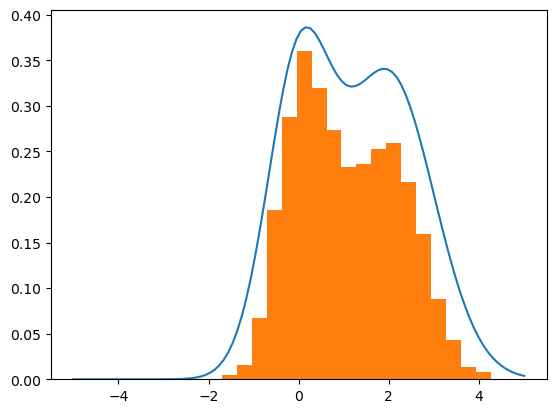

In [316]:
# try again

# target distribution / posterior: = P(x)
def posterior_pdf(x):
    return np.exp(-x**2) + np.exp(-(x-2)**2 * 1/2)

# proposal function: =Q(x|xt), xt=prev value
def proposal_pdf(x, xt):
    return scipy.stats.norm(loc=xt, scale=1).pdf(x) # normal with scale=1, mean=mu, mu=xt (prev value), x=x

def proposal_func(x):
    return np.random.normal(x, 1) # normal with scale=1, mean=x

P = lambda x: np.exp(-x**2) + np.exp(-(x-2)**2 * 1/2)
Q = lambda x, xt: scipy.stats.norm(loc=xt, scale=1).pdf(x)

def mcmc_known_posterior(proposal_func, P, Q):
    samples = []
    xs = np.linspace(-5, 5, 100)

    xt = proposal_func(0) # xt = proposal/ candidate, generate first state
    
    for i in range(100000):
        xt = metropolis_known_posterior(xt, proposal_func, P, Q)
        samples.append(xt)

    plt.figure()
    plt.plot(xs, P(xs)/3)
    plt.hist(samples[1000:], bins=20, density=True)
    plt.show()

    return 

def metropolis_known_posterior(xt, proposal_func, P, Q):
    proposed = proposal_func(xt)
    acceptance_ratio = P(proposed) * Q(xt, proposed) / P(xt) * Q(proposed, xt)
    p = np.random.uniform(0,1)
    if p < acceptance_ratio:
        xt = proposed
    return xt

mcmc_known_posterior(proposal_func, P, Q)


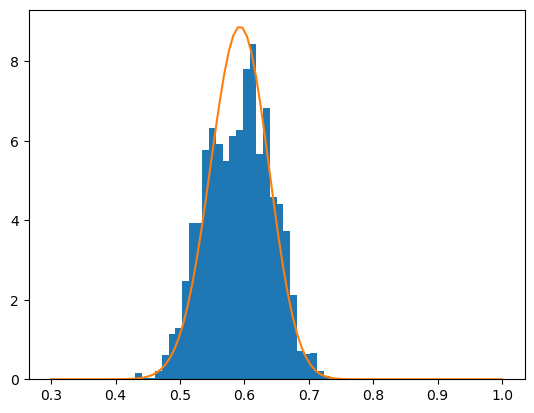

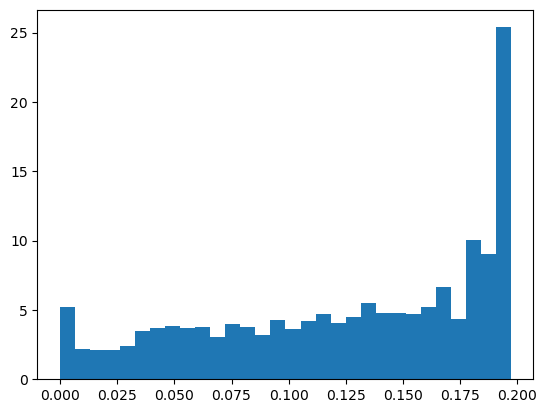

In [406]:
# reference: https://people.duke.edu/~ccc14/sta-663/mcmc.html

# mcmc unknown posterior: posterior = prior * likelihoood
def prior_pdf(theta):
    return scipy.stats.beta(10,10).pdf(theta)

def likelihood(x):
    return scipy.stats.binom(100, theta).pmf(61)

def est_posterior(prior, likelihood, n, p, x):
    return prior(x) * likelihood(x, n, p)

n = 100
k = 61
p = k/n
# pretend thse are estimated from data of coin flips

# trying to find a theta (sampling theta as x)

# proposal function: =Q(x|xt), xt=prev value
def proposal_pdf(theta, thetat):
    return scipy.stats.norm(loc=thetat, scale=1).pdf(theta) # normal with scale=1, mean=mu, mu=xt (prev value), x=x

def proposal_func(x):
    return np.random.normal(x, 0.3) # normal with scale=1, mean=x

P = lambda theta: scipy.stats.beta(10,10).pdf(theta) * np.exp(np.log(scipy.stats.binom(100, theta).pmf(61))) if 0<=theta<=1 else 10**-10
Q = lambda theta, thetat: scipy.stats.norm(loc=thetat, scale=0.3).pdf(theta)


def mcmc_unknown_posterior(proposal_func, P, Q, log=False):
    samples = np.array([])
    estimated_posteriors = np.array([])

    xt = proposal_func(0) # xt = proposal/ candidate, generate first state
    Pxt = P(xt)
    
    for i in range(10000):
        xt, Pxt = metropolis_unknown_posterior(xt, proposal_func, P, Q, Pxt, log=log)
        samples = np.append(samples, xt)
        estimated_posteriors = np.append(estimated_posteriors, Pxt)

    return samples, estimated_posteriors

def metropolis_unknown_posterior(xt, proposal_func, P, Q, Pxt, log):
    proposed = proposal_func(xt)
    P_proposed = P(proposed)

    if log==True:
        acceptance_ratio = min(0, np.log(P_proposed * Q(xt, proposed) / Pxt * Q(proposed, xt)))
    else:
        acceptance_ratio = min(1, P_proposed * Q(xt, proposed) / Pxt * Q(proposed, xt))

    p = np.random.uniform(0,1)

    if log == True:
        p = np.log(p)

    if p < acceptance_ratio:
        xt = proposed
        Pxt = P_proposed
    return xt, Pxt

s, e = mcmc_unknown_posterior(proposal_func, P, Q, log=True)

plt.figure()
plt.hist(s[s>=0][100:], bins=30, density=True)
xs = np.linspace(0.3, 1, 100)
plt.plot(xs, scipy.stats.beta(k+10, n-k+10).pdf(xs))
plt.show()

plt.figure()
plt.hist(e, bins=30, density=True)
plt.show()

In [481]:
def mcmc(params, proposal_func, P, Q, rng, num_iter=10000, log=False):
    """
    params: starting vector of parameters

    proposal_func: a function that accepts a vector of parameters and an rng and generates a single value, as the proposed next state, as well as
    the perturbed parameters

    P: a function that accepts a single value (state) and generates a posterior: prior * likelihood, NOT the log likelihood or it will not work :( 
    but np.exp(a log likelihood) within P should be okay

    Q: a function that accepts two states - the proposed state and the previous accepted state, and generates the pdf under the proposal function

    log: True if want to use log likelihood etc (i think)
    """
    samples = np.array([])
    estimated_posteriors = np.array([])
    parameters = np.array([])

    xt, par = proposal_func(params, rng) # xt = proposal/ candidate, generate first state
    Pxt = P(xt)
    
    for i in range(num_iter):
        xt, Pxt, par = mc_update(xt, Pxt, par, proposal_func, P, Q, rng, log=log)
        samples = np.append(samples, xt)
        estimated_posteriors = np.append(estimated_posteriors, Pxt)
        parameters = np.append(parameters, par)

    return samples, estimated_posteriors, parameters

def mc_update(xt, Pxt, params, proposal_func, P, Q, rng, log):

    proposed, par = proposal_func(params, rng)
    P_proposed = P(proposed)

    if log==True:
        acceptance_ratio = min(0, (P_proposed - Pxt + np.log(Q(xt, proposed)) - np.log(Q(proposed, xt))))
    else:
        acceptance_ratio = min(1, P_proposed * Q(xt, proposed) / (Pxt * Q(proposed, xt)))

    p = np.random.uniform(0,1)

    if log == True:
        p = np.log(p)

    if p < acceptance_ratio:
        return proposed, P_proposed, par
    
    return xt, Pxt, params


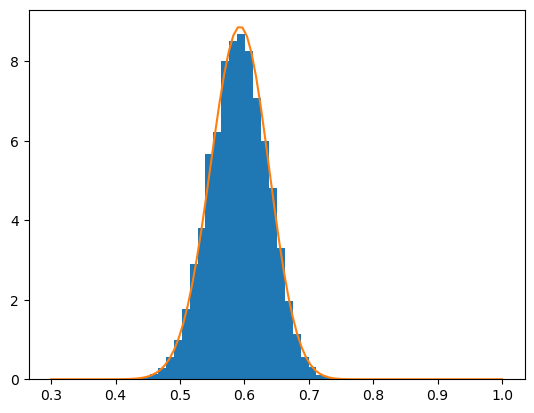

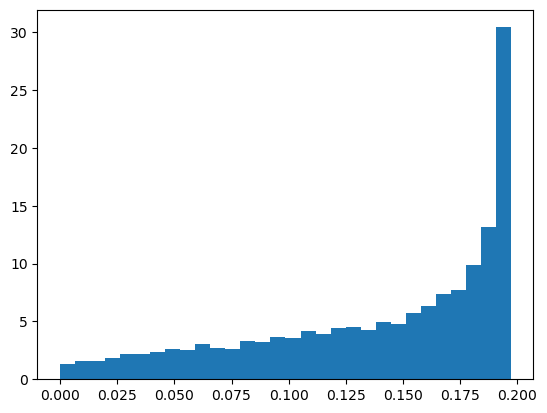

In [484]:
def proposal_pdf(x, xt):
    return scipy.stats.norm(loc=xt, scale=1).pdf(x) # normal with scale=1, mean=mu, mu=xt (prev value), x=x

def proposal_func(x, rng):
    v = np.random.normal(x, 0.3)
    return v, v  # normal with scale=.3, mean=x

P = lambda x: scipy.stats.beta(10,10).pdf(x) * np.exp(np.log(scipy.stats.binom(100, x).pmf(61))) if 0<=x<=1 else 10**-10
Q = lambda x, xt: scipy.stats.norm(loc=xt, scale=0.3).pdf(x)

params = 0
s, e, p = mcmc(params, proposal_func, P, Q, rng=np.random.default_rng(),num_iter=90000)

plt.figure()
plt.hist(s[s>=0][1000:], bins=30, density=True)
xs = np.linspace(0.3, 1, 100)
n = 100
k = 61
plt.plot(xs, scipy.stats.beta(k+10, n-k+10).pdf(xs))
plt.show()

plt.figure()
plt.hist(e, bins=30, density=True)
plt.show()


In [478]:
# generalize; def mcmc(some function that takes in a vector and returns a single value, parameters, a random seed, a proposal function)
# sum first col of eval_ds to get overall likelihood
# return parameters, log likelihoods of each
# proposal functions: works better in log space due to likely ranges
# perturb parameters by some amount of noise to generate proposal: amount of noise to add (step size) (alter step size depending on parameters since they all have different likely ranges)
# test on something easy to verify, gaussian etc

from abm_ll import eval_ds
from city_data import subsampled_city_data
from stat_utils import CityParams, GeneralParams

params = GeneralParams(propensity=1e-8, walk_radius=40, arm_bias=1.0, arm_weight=1.0, atrisk_gathering_rate=1e-8)
timespan = 50
rng_key = jrand.PRNGKey(42)
rng_key, subkey = jrand.split(rng_key, 2)

def proposal_func(params, rng):
    p = np.random.normal(params, np.array([1, ]))
    eval_result = eval_ds(subsampled_city_data, p, timespan, rng_key)
    return eval_result, p

def logP(eval_result):
    likelihood = sum(eval_result[:,0])
    return likelihood 

# Q = lambda x, xt: scipy.stats.norm(loc=xt, scale=0.3).pdf(x)

def Q(params, params_t): #??? would this work
    return np.prod(scipy.stats.norm(loc=params_t, scale=1).pdf(params))



FileNotFoundError: [Errno 2] No such file or directory: 'data/county_data.pkl'

In [480]:
h = np.array([[1,2,3],[4,5,6]])
sum(h[:,0])

5

In [ ]:

# def eval_ds(city_data, general_params, timespan, rng_key, num_samples=10000):
#     ll_data = []
#     for c in city_data:
#         rng_key, subkey = jrand.split(rng_key, 2)
#         c_params = c['params']
#         c_events = c['events']
#         event_sim = conditional_sample(c_params, general_params, subkey, num_samples=num_samples)
#         city_distr = grenander_pdf(event_sim+1)
#         ll, pll, eventll = city_ll(c_params, c_events, general_params, timespan, city_distr)
#         ll_data.append([ll, pll, eventll])
#     return np.array(ll_data)



    # with open('data/county_data.pkl', 'rb') as f:
    #     city_data = pickle.load(f)

    # def hasna(p):
    #     return any(np.isnan(x) for x in p)

    # city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}
    # city_data_f = [c for c in city_data.values() if c['events']]
    # city_data_base = [c for c in city_data.values() if not c['events']]
    # city_base_ind = np.arange(len(city_data_base))

    # np.random.seed(1)
    # np.random.shuffle(city_base_ind)
    # subsampled_city_data_base = np.array(city_data_base)[city_base_ind[:400]]
    # subsampled_city_data = np.concatenate([city_data_f, subsampled_city_data_base])

    # c = subsampled_city_data[10]
    # params = GeneralParams(propensity=1e-8, walk_radius=40, arm_bias=1.0, arm_weight=1.0, atrisk_gathering_rate=1e-8)
    # c_params = c['params']
    # c_events = c['events']

    # curr = conditional_sample(c_params, params, jrand.PRNGKey(i), num_samples=int(1e5))
    # city_distr = grenander_pdf(curr+1)
    # curr_ll, pll, eventll = city_ll(c_params, c_events, params, 50, city_distr)

